Saving 5. Classify Customer Churn.csv to 5. Classify Customer Churn (1).csv
Accuracy: 0.7853589196872779

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



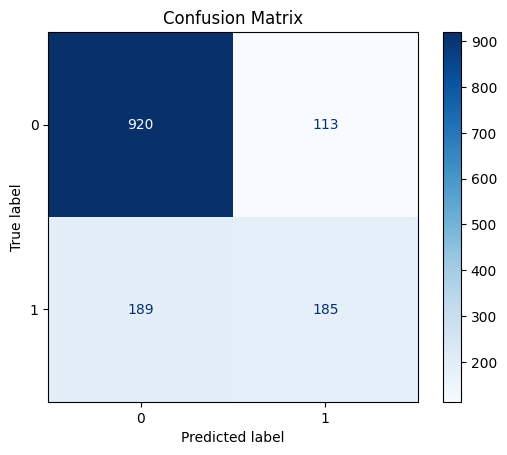

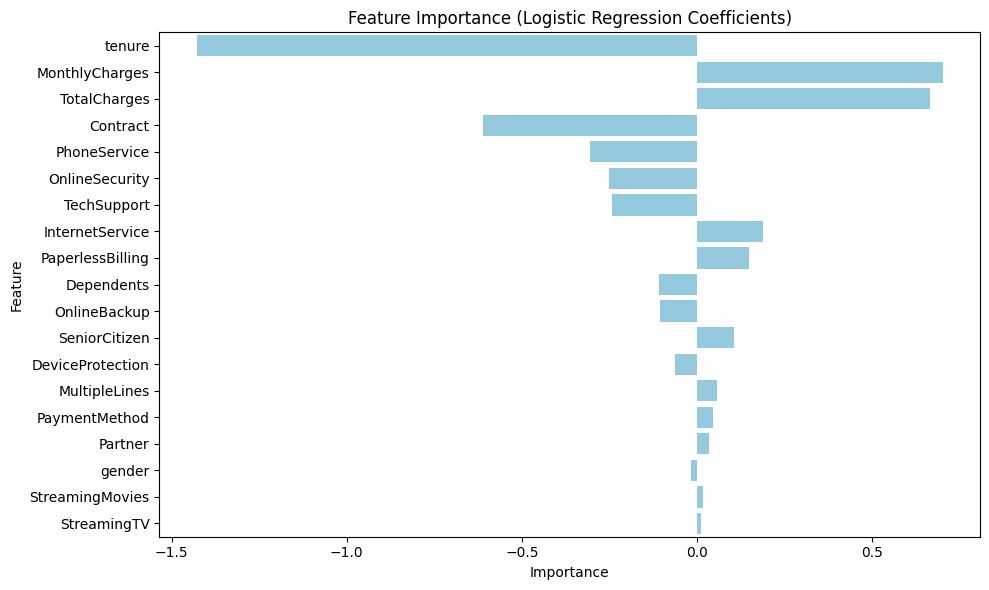

In [3]:
# STEP 1: Upload CSV from your computer
from google.colab import files
uploaded = files.upload()

import pandas as pd
import io

# Automatically read the uploaded file (assuming only one CSV is uploaded)
df = pd.read_csv(io.BytesIO(next(iter(uploaded.values()))))

# STEP 2: Drop CustomerID
df.drop('customerID', axis=1, inplace=True)

# STEP 3: Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# STEP 4: Handle Missing Values
df.dropna(inplace=True)

# STEP 5: Encode Categorical Columns
from sklearn.preprocessing import LabelEncoder

label_enc = LabelEncoder()
df['Churn'] = label_enc.fit_transform(df['Churn'])  # Target column

for col in df.select_dtypes(include='object').columns:
    df[col] = label_enc.fit_transform(df[col])

# STEP 6: Feature/Target Split
X = df.drop('Churn', axis=1)
y = df['Churn']

# STEP 7: Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# STEP 8: Train/Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

#  STEP 9: Model Training
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# STEP 10: Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix Plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

# Feature Importance Plot (clean, no warnings)
importance = model.coef_[0]
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', color='skyblue')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.tight_layout()
plt.show()
